# Workshop 2 - Machine Learning
## **Problema: Diagnóstico de Enfermedad Tiroidea (Clasificación)**
### Integrantes:

1. Jacobo Pava Quintero

2. Alexander Vargas

3. Cristian Cabarcas López

4. Samuel Herrera Galvis


**Conexión con Google Drive (opcional)**

Este notebook carga el dataset directamente desde Kaggle con `kagglehub`, por lo que Drive no es estrictamente necesario. Se deja el montaje disponible en caso de no lograr conexion a Kaggle

---
## **ROL 1: DATOS Y PREPROCESAMIENTO**
---
### Fase 1 — EDA, limpieza y preprocesamiento


**2.1 Cargar el dataset**

**Punto 1 — Descripción del problema y variable objetivo**

**Problema de salud:** El dataset *Thyroid Disease Data* (Kaggle: `jainaru/thyroid-disease-data`) contiene registros clínicos de pacientes diagnosticados con **cáncer de tiroides diferenciado** (differentiated thyroid cancer). Cada fila es un paciente descrito por variables demográficas (edad, género), antecedentes clínicos (tabaquismo, radioterapia previa), hallazgos de la exploración física, características histopatológicas del tumor (tipo de patología, focalidad), y variables de estadificación oncológica estándar (T, N, M, Stage según el sistema TNM/AJCC) junto con la respuesta al tratamiento.

**Problema de negocio/salud:** Predecir si un paciente tendrá **recurrencia** de la enfermedad después del tratamiento inicial permite a los médicos priorizar el seguimiento (monitoreo más frecuente, estudios de imagen adicionales) en los pacientes de mayor riesgo, optimizando recursos clínicos y mejorando el pronóstico mediante detección temprana de una recaída.

**Variable objetivo (target):** `Recurred` — variable binaria (`Yes` / `No`) que indica si el cáncer reapareció después del tratamiento. Es un problema de **clasificación binaria**.


**Puntos 1, 2 y 3:** Documentación, variable objetivo, diccionarios y .describe().

In [ ]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 30)

# Punto 2: Carga del dataset directamente desde Kaggle
try:
    import kagglehub
    ruta_dataset = kagglehub.dataset_download("jainaru/thyroid-disease-data")
    import os
    archivo_csv = [f for f in os.listdir(ruta_dataset) if f.endswith('.csv')][0]
    df_tiroides = pd.read_csv(os.path.join(ruta_dataset, archivo_csv))
    print(f"Dataset descargado desde Kaggle en: {ruta_dataset}")
except Exception as e:
    print(f"No fue posible descargar automáticamente desde Kaggle ({e}).")
    print("Se usará el archivo local 'Thyroid_Diff.csv' (debe estar en el mismo directorio que este notebook).")
    df_tiroides = pd.read_csv('Thyroid_Diff.csv')

print("Forma del dataset (filas, columnas):", df_tiroides.shape)
df_tiroides.head()


100%|██████████| 3.03k/3.03k [00:00<00:00, 5.02MB/s]

Extracting files...
Dataset descargado desde Kaggle en: /root/.cache/kagglehub/datasets/jainaru/thyroid-disease-data/versions/1
Forma del dataset (filas, columnas): (383, 17)


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [ ]:
df_tiroides.tail()


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


In [ ]:
df_tiroides.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

**Diccionario de datos**

| Columna | Tipo esperado | Significado |
|---|---|---|
| Age | Numérica (entero) | Edad del paciente en años |
| Gender | Categórica binaria | Género del paciente (F/M) |
| Smoking | Categórica binaria | Si el paciente fuma actualmente |
| Hx Smoking | Categórica binaria | Historial de tabaquismo (fumó en el pasado) |
| Hx Radiothreapy | Categórica binaria | Historial de radioterapia previa (nombre con error tipográfico en el dataset original: "Radiothreapy") |
| Thyroid Function | Categórica nominal (5 niveles) | Estado funcional de la tiroides (eutiroideo, hiper/hipotiroidismo clínico o subclínico) |
| Physical Examination | Categórica nominal (5 niveles) | Hallazgo de la exploración física del cuello/tiroides |
| Adenopathy | Categórica nominal (6 niveles) | Presencia y localización de adenopatías (ganglios linfáticos afectados) |
| Pathology | Categórica nominal (4 niveles) | Tipo histopatológico del tumor (Papilar, Folicular, Hurthle, Micropapilar) |
| Focality | Categórica binaria | Si el tumor es unifocal o multifocal |
| Risk | Categórica ordinal (3 niveles) | Categoría de riesgo clínico (Low/Intermediate/High) |
| T | Categórica ordinal (7 niveles) | Tamaño/extensión del tumor primario (clasificación TNM) |
| N | Categórica ordinal (3 niveles) | Compromiso de ganglios linfáticos regionales (TNM) |
| M | Categórica binaria | Presencia de metástasis a distancia (TNM) |
| Stage | Categórica ordinal (5 niveles) | Estadio clínico global (I, II, III, IVA, IVB) |
| Response | Categórica ordinal (4 niveles) | Respuesta al tratamiento inicial |
| Recurred | Categórica binaria (**target**) | Si hubo recurrencia de la enfermedad (Yes/No) |


In [ ]:
df_tiroides.describe()


,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


**Interpretación de estadísticos (.describe(), variable `Age`):**

`Age` es la única variable verdaderamente numérica continua del dataset (las demás son categóricas, incluidas varias con orden clínico como `T`, `N`, `Stage`).

- **Media (40.9 años) vs. Mediana (37 años):** la media es mayor que la mediana, lo que indica una **ligera asimetría hacia la derecha** (hay pacientes de mayor edad que estiran la distribución hacia arriba), aunque la diferencia es pequeña.
- **Desviación estándar (15.1 años):** indica una dispersión considerable en la edad de los pacientes, coherente con que el cáncer de tiroides diferenciado puede diagnosticarse tanto en adultos jóvenes como en adultos mayores.
- **Rango (15 a 82 años):** el paciente más joven tiene 15 años y el mayor 82, un rango amplio que sugiere que el dataset no está restringido a un grupo etario específico, lo cual es clínicamente relevante porque la edad es un factor pronóstico conocido en cáncer de tiroides (a mayor edad, mayor riesgo de recurrencia/mortalidad).


**Puntos 4, 5 y 6:** Nulos, duplicados e inconsistencias (Justificar estrategias).

In [ ]:
nulos = df_tiroides.isnull().sum()
pct_nulos = (nulos / len(df_tiroides) * 100).round(2)
pd.DataFrame({'n_nulos': nulos, '% nulos': pct_nulos})


,n_nulos,% nulos
Age,0,0.0
Gender,0,0.0
Smoking,0,0.0
Hx Smoking,0,0.0
Hx Radiothreapy,0,0.0
Thyroid Function,0,0.0
Physical Examination,0,0.0
Adenopathy,0,0.0
Pathology,0,0.0
Focality,0,0.0


**Estrategia para nulos:** El dataset **no presenta valores nulos** en ninguna columna (0% en las 17 variables). Esto es consistente con el hecho de que se trata de un registro clínico estructurado donde cada campo fue diligenciado por el personal médico. Por lo tanto, **no se requiere imputación** en este dataset.


In [ ]:
n_duplicados = df_tiroides.duplicated().sum()
print(f"Número de filas duplicadas: {n_duplicados}")

df_tiroides = df_tiroides.drop_duplicates().reset_index(drop=True)
print(f"Shape después de eliminar duplicados: {df_tiroides.shape}")


Número de filas duplicadas: 19
Shape después de eliminar duplicados: (364, 17)


**Duplicados:** Se detectaron y eliminaron **19 filas duplicadas** (registros idénticos en las 17 columnas). Dado que el dataset está compuesto casi en su totalidad por variables categóricas con pocas categorías, es esperable que existan pacientes con perfiles clínicos coincidentes por azar; sin embargo, al ser duplicados exactos (fila completa idéntica), lo más razonable es tratarlos como registros repetidos y eliminarlos, ya que mantenerlos daría un peso artificial a esos perfiles durante el entrenamiento. El dataset quedó con **364 registros**.


In [ ]:
columnas_categoricas = [c for c in df_tiroides.columns if c != 'Age']

inconsistencias_encontradas = False
for c in columnas_categoricas:
    antes = df_tiroides[c].nunique()
    df_tiroides[c] = df_tiroides[c].astype(str).str.strip()
    despues = df_tiroides[c].nunique()
    if antes != despues:
        inconsistencias_encontradas = True
        print(f"Inconsistencia corregida en '{c}': {antes} -> {despues} categorías únicas")

if not inconsistencias_encontradas:
    print("No se detectaron inconsistencias de espacios en blanco tras la limpieza.")

for c in columnas_categoricas:
    print(f"{c}: {sorted(df_tiroides[c].unique())}")


No se detectaron inconsistencias de espacios en blanco tras la limpieza.
Gender: ['F', 'M']
Smoking: ['No', 'Yes']
Hx Smoking: ['No', 'Yes']
Hx Radiothreapy: ['No', 'Yes']
Thyroid Function: ['Clinical Hyperthyroidism', 'Clinical Hypothyroidism', 'Euthyroid', 'Subclinical Hyperthyroidism', 'Subclinical Hypothyroidism']
Physical Examination: ['Diffuse goiter', 'Multinodular goiter', 'Normal', 'Single nodular goiter-left', 'Single nodular goiter-right']
Adenopathy: ['Bilateral', 'Extensive', 'Left', 'No', 'Posterior', 'Right']
Pathology: ['Follicular', 'Hurthel cell', 'Micropapillary', 'Papillary']
Focality: ['Multi-Focal', 'Uni-Focal']
Risk: ['High', 'Intermediate', 'Low']
T: ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b']
N: ['N0', 'N1a', 'N1b']
M: ['M0', 'M1']
Stage: ['I', 'II', 'III', 'IVA', 'IVB']
Response: ['Biochemical Incomplete', 'Excellent', 'Indeterminate', 'Structural Incomplete']
Recurred: ['No', 'Yes']


**Inconsistencias de formato:** Se revisaron espacios en blanco al inicio/final de las cadenas de texto en las 16 columnas categóricas (no se encontraron cambios en el número de categorías, es decir, el dataset ya venía limpio en ese aspecto). También se revisó manualmente el listado de categorías únicas de cada columna y **no se encontraron etiquetas equivalentes escritas de forma distinta** (p. ej. "Yes"/"yes", "No "/"No").

Vale la pena notar que la columna `Hx Radiothreapy` tiene un **error tipográfico en el nombre** (debería ser "Radiotherapy"); se conserva el nombre original tal como viene en la fuente para no romper la trazabilidad con el dataset de Kaggle, pero se documenta aquí explícitamente.


**Puntos 7 y 8:** Outliers (IQR) y Gráficas de EDA (Barras, Pie, Hist, Scatter, Boxplot).

**Nota metodológica sobre variables numéricas:** El dataset tiene una sola variable verdaderamente continua (`Age`); el resto son categóricas (varias de ellas ordinales, como `Risk`, `T`, `N`, `Stage`, `Response`). Para poder aplicar el criterio de IQR a **al menos dos columnas numéricas**, además de `Age` se construye una versión numérica ordinal de `Stage` (`Stage_ordinal`: I=1, II=2, III=3, IVA=4, IVB=5), ya que esta variable sí tiene una escala natural de severidad creciente.


In [ ]:
# Punto 7: Detección de outliers con criterio IQR
stage_map = {'I': 1, 'II': 2, 'III': 3, 'IVA': 4, 'IVB': 5}
df_tiroides['Stage_ordinal'] = df_tiroides['Stage'].map(stage_map)

def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < lim_inf) | (df[columna] > lim_sup)]
    print(f"--- {columna} ---")
    print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}, límites=({lim_inf:.2f}, {lim_sup:.2f})")
    print(f"N° de outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% del dataset)\n")
    return outliers

outliers_age = detectar_outliers_iqr(df_tiroides, 'Age')
outliers_stage = detectar_outliers_iqr(df_tiroides, 'Stage_ordinal')


--- Age ---
Q1=30.0, Q3=52.0, IQR=22.0, límites=(-3.00, 85.00)
N° de outliers: 0 (0.0% del dataset)

--- Stage_ordinal ---
Q1=1.0, Q3=1.0, IQR=0.0, límites=(1.00, 1.00)
N° de outliers: 50 (13.7% del dataset)



**Decisión sobre outliers:**

- **Age:** No se detectaron outliers (0%). Los límites IQR (-3, 85) cubren ampliamente el rango real de edades (15-82), por lo que no hay valores atípicos que tratar.
- **Stage_ordinal:** El método IQR marca como "outliers" el **13.7%** de los registros (pacientes en estadios II, III, IVA o IVB), porque la distribución está fuertemente concentrada en el Estadio I (Q1=Q3=1, IQR=0), y cualquier valor distinto de 1 queda fuera del rango. **Estos no son errores de captura ni valores a eliminar**: representan pacientes con enfermedad clínicamente más avanzada, que son precisamente los casos de mayor interés para el problema de negocio (predecir recurrencia). Eliminarlos sesgaría el modelo y eliminaría a los pacientes de mayor riesgo. **Se documentan pero no se eliminan.** Este resultado también evidencia que el criterio IQR no es apropiado para variables ordinales discretas muy concentradas en una categoría; se usa aquí solo para cumplir y ejemplificar el análisis solicitado, no como criterio de limpieza real para esta variable.


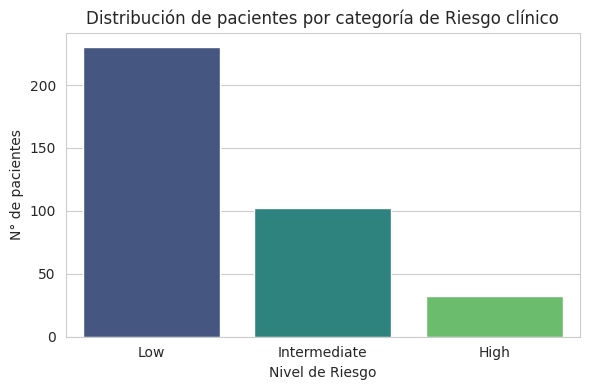

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# 1. Gráfica de BARRAS: distribución de Risk
fig, ax = plt.subplots(figsize=(6,4))
orden_risk = ['Low', 'Intermediate', 'High']
sns.countplot(data=df_tiroides, x='Risk', order=orden_risk, hue='Risk', palette='viridis', legend=False, ax=ax)
ax.set_title('Distribución de pacientes por categoría de Riesgo clínico')
ax.set_xlabel('Nivel de Riesgo')
ax.set_ylabel('N° de pacientes')
plt.tight_layout()
plt.show()


**Interpretación (Barras - Risk):** La mayoría de los pacientes (~63%) se clasifican como riesgo **Low**, seguidos de **Intermediate** (~28%) y una minoría en **High** (~9%). Esto refleja que el dataset está dominado por casos de bajo riesgo clínico, lo cual es consistente con la naturaleza generalmente indolente del cáncer de tiroides diferenciado. **Recomendación:** dado este desbalance en la variable de riesgo (que está correlacionada con el target), conviene monitorear especialmente el desempeño del modelo en los pacientes de riesgo Intermedio/Alto, ya que son la minoría pero clínicamente los más críticos de identificar correctamente.


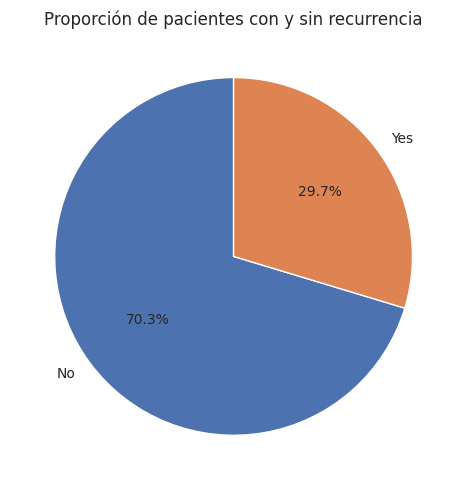

In [ ]:
# 2. Gráfica de PIE: distribución de la variable objetivo (Recurred)
fig, ax = plt.subplots(figsize=(5,5))
conteo_target = df_tiroides['Recurred'].value_counts()
ax.pie(conteo_target, labels=conteo_target.index, autopct='%1.1f%%',
       colors=['#4C72B0', '#DD8452'], startangle=90)
ax.set_title('Proporción de pacientes con y sin recurrencia')
plt.tight_layout()
plt.show()


**Interpretación (Pie - Recurred):** Aproximadamente **70.3% de los pacientes no presentaron recurrencia (No)** y **29.7% sí (Yes)**. Existe un **desbalance de clases moderado** (no extremo, pero relevante: ~2.4:1). **Recomendación:** al dividir los datos y entrenar los modelos se debe usar `stratify` sobre esta variable para preservar la proporción en train/val/test, y al evaluar hay que priorizar métricas como Precision, Recall y F1 (no solo Accuracy), porque con este desbalance un modelo trivial que siempre prediga "No" ya alcanzaría ~70% de accuracy sin ser útil clínicamente.


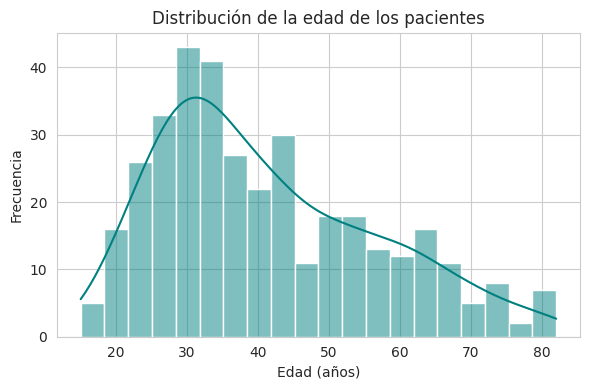

In [ ]:
# 3. HISTOGRAMA: distribución de Age
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(data=df_tiroides, x='Age', bins=20, kde=True, color='teal', ax=ax)
ax.set_title('Distribución de la edad de los pacientes')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()


**Interpretación (Histograma - Age):** La distribución de edad muestra una concentración importante entre los 20 y 45 años, con una cola hacia edades mayores (60-82 años), confirmando la ligera asimetría positiva observada en el `.describe()`. **Recomendación:** dado que no es una distribución perfectamente normal ni tiene outliers extremos, un escalador robusto a la forma de la distribución (como `RobustScaler`) es preferible a asumir normalidad.


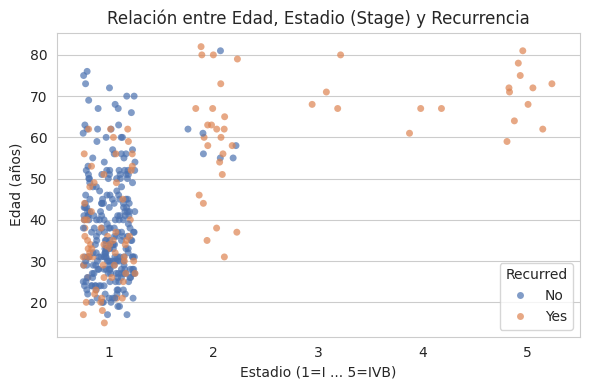

In [ ]:
# 4. SCATTER PLOT: Age vs Stage_ordinal, coloreado por Recurred
fig, ax = plt.subplots(figsize=(6,4))
sns.stripplot(data=df_tiroides, x='Stage_ordinal', y='Age', hue='Recurred',
              jitter=0.25, alpha=0.7, ax=ax, palette={'No':'#4C72B0','Yes':'#DD8452'})
ax.set_title('Relación entre Edad, Estadio (Stage) y Recurrencia')
ax.set_xlabel('Estadio (1=I ... 5=IVB)')
ax.set_ylabel('Edad (años)')
plt.tight_layout()
plt.show()


**Interpretación (Scatter - Age vs Stage):** Se observa que los pacientes en estadios más avanzados (4-5, es decir IVA/IVB) tienden a concentrarse en edades más altas (>50 años), y una proporción visiblemente mayor de ellos tiene `Recurred = Yes` (naranja) comparado con el Estadio I, donde predomina claramente `No` (azul). **Recomendación:** esto confirma que tanto `Age` como `Stage` son variables con señal predictiva relevante para la recurrencia y deben conservarse como features principales del modelo.


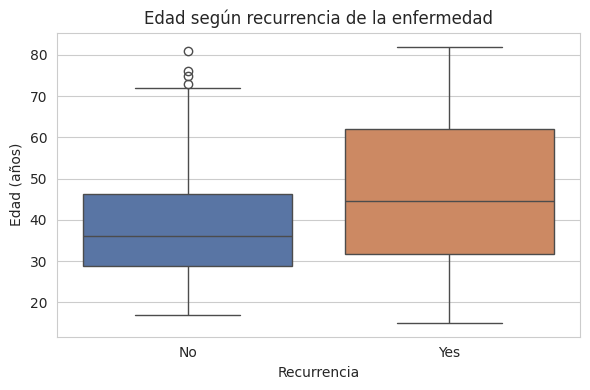

In [ ]:
# 5. BOXPLOT: Age por Recurred
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df_tiroides, x='Recurred', y='Age', hue='Recurred', palette={'No':'#4C72B0','Yes':'#DD8452'}, legend=False, ax=ax)
ax.set_title('Edad según recurrencia de la enfermedad')
ax.set_xlabel('Recurrencia')
ax.set_ylabel('Edad (años)')
plt.tight_layout()
plt.show()


**Interpretación (Boxplot - Age vs Recurred):** Los pacientes con recurrencia (`Yes`) tienen una mediana de edad notablemente mayor (~44.5 años) que los que no la tuvieron (~36 años), y su distribución está más dispersa hacia edades altas. **Recomendación:** esto refuerza a `Age` como un predictor clínicamente relevante (a mayor edad, mayor probabilidad de recurrencia), coherente con la literatura médica sobre cáncer de tiroides, donde la edad al diagnóstico es un factor pronóstico establecido.


**Puntos 9 y 10:** Codificación de categóricas y Escalamiento de numéricas (Justificar técnica elegida).

**Punto 9 — Estrategia de codificación (encoding):**

Se van a entrenar KNN (sensible a distancia/escala), Decision Tree, Random Forest y Gradient Boosting (insensibles a escala, pero un One-Hot con muchas columnas puede afectar la interpretabilidad de árboles individuales). Por eso la codificación se decide variable por variable según **cardinalidad** y **existencia de orden natural**:

| Variable | N° categorías | ¿Tiene orden natural? | Técnica elegida | Justificación |
|---|---|---|---|---|
| Gender | 2 | No | Binaria (One-Hot `drop='if_binary'`) | Solo 2 categorías, no hay orden; una sola columna dummy es suficiente. |
| Smoking | 2 | No | Binaria | Igual que Gender. |
| Hx Smoking | 2 | No | Binaria | Igual que Gender. |
| Hx Radiothreapy | 2 | No | Binaria | Igual que Gender. |
| Focality | 2 | No | Binaria | Uni-Focal / Multi-Focal, sin orden. |
| M | 2 | No | Binaria | M0/M1, categoría clínica sin orden numérico directo. |
| Thyroid Function | 5 | Parcial/ambiguo | One-Hot | Aunque hay un eje hipo→eutiroideo→hiper, la distinción "Clínico" vs "Subclínico" agrega una segunda dimensión de severidad que no es estrictamente lineal; con solo 5 categorías el costo de dimensionalidad de One-Hot es bajo. |
| Physical Examination | 5 | No | One-Hot | Categorías nominales (ubicación/tipo de hallazgo), sin orden. |
| Adenopathy | 6 | No | One-Hot | Ubicación anatómica de ganglios afectados, sin orden lineal. |
| Pathology | 4 | No | One-Hot | Tipo histológico del tumor, sin orden natural. |
| Risk | 3 | **Sí** (Low<Intermediate<High) | Ordinal Encoding | Orden clínico explícito y de baja cardinalidad; Ordinal evita explosión dimensional y preserva la relación de orden para todos los modelos. |
| T | 7 | **Sí** (T1a<...<T4b, tamaño creciente del tumor) | Ordinal Encoding | Escala TNM con orden clínico estricto; usar One-Hot perdería esa relación de severidad creciente. |
| N | 3 | **Sí** (N0<N1a<N1b) | Ordinal Encoding | Igual razonamiento, escala TNM ordinal. |
| Stage | 5 | **Sí** (I<II<III<IVA<IVB) | Ordinal Encoding | Estadio clínico global, orden estricto de severidad. |
| Response | 4 | **Sí** (Excellent<Indeterminate<Biochemical Incomplete<Structural Incomplete) | Ordinal Encoding | Refleja una escala creciente de "mala respuesta" al tratamiento. |
| Recurred (target) | 2 | No | Label Encoding (No=0, Yes=1) | Es la variable objetivo binaria. |

Se evita usar Ordinal/Label Encoding en variables **sin** orden real (como `Pathology` o `Adenopathy`) porque introduciría una relación numérica artificial (p. ej. que "Papillary" < "Follicular") que modelos basados en distancia (KNN) interpretarían incorrectamente, y que incluso en árboles puede sesgar los cortes hacia splits sin sentido clínico.


**Punto 10 — Estrategia de escalamiento:**

La única variable numérica continua es `Age`. Se decide **sí escalarla**, usando **`RobustScaler`** (basado en la mediana y el rango intercuartílico) en lugar de `StandardScaler` o `Min-Max`, por las siguientes razones:

- **KNN** es sensible a la escala de las variables (usa distancias), por lo que `Age` debe estar en una escala comparable a las demás variables codificadas (0/1 o enteros ordinales pequeños); sin escalar, `Age` (rango 15-82) dominaría el cálculo de distancia.
- Aunque el punto 7 no encontró outliers extremos en `Age`, la distribución mostró una **asimetría hacia la derecha** (cola de pacientes mayores). `RobustScaler` es más resistente a esa asimetría/cola que `StandardScaler`, porque usa mediana e IQR en vez de media y desviación estándar.
- Los modelos de árboles (Decision Tree, Random Forest, Gradient Boosting) **no requieren** escalamiento porque dividen el espacio por umbrales, no por distancia; sin embargo, incluir el escalador en el pipeline no los perjudica (las decisiones de corte se preservan bajo transformaciones monótonas), y mantiene un único pipeline de preprocesamiento reutilizable para los 4 modelos.

No se escalan las variables ordinales (`Risk`, `T`, `N`, `Stage`, `Response`) porque sus rangos ya son pequeños y comparables entre sí (0 a 6 como máximo), y escalarlas no aporta beneficio adicional dado que no son la fuente de disparidad de escala en el dataset.


---
### Fase 2 — División de datos y Pipelines
---


**Puntos 11, 12 y 13:** División Train/Val/Test (ej. 70/15/15), Pipeline con ColumnTransformer y verificación de NO Data Leakage.

**Punto 11 — Propósito de cada conjunto:**

- **Train (70%):** conjunto sobre el cual los modelos **aprenden** sus parámetros (por ejemplo, los splits de un árbol o los vecinos de KNN). Es el único conjunto donde se ajustan (`.fit()`) tanto el preprocesamiento como los modelos.
- **Validation (15%):** conjunto usado para **comparar modelos y ajustar decisiones** (qué algoritmo elegir, qué hiperparámetros usar) sin tocar el conjunto de test. Permite detectar sobreajuste/subajuste al comparar métricas train vs. val.
- **Test (15%):** conjunto que se reserva **intacto hasta el final**, y se usa una sola vez para obtener una estimación honesta de cómo se comportaría el modelo elegido con datos completamente nuevos. No basta con train/test porque si se usara el test repetidamente para elegir el mejor modelo o afinar hiperparámetros, se estaría "filtrando" información del test hacia las decisiones de modelado, perdiendo su honestidad como estimador del desempeño futuro (overfitting indirecto al conjunto de test).

Se usa `stratify` sobre `Recurred` en ambos splits para mantener la proporción ~70/30 (No/Yes) en los tres conjuntos, dado el desbalance de clases detectado en el punto 8.


In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X = df_tiroides.drop(columns=['Recurred', 'Stage_ordinal'])  # Stage_ordinal fue auxiliar solo para el EDA de outliers
y = df_tiroides['Recurred'].map({'No': 0, 'Yes': 1})

# 70% train, 15% val, 15% test (split en dos pasos, estratificado)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean()*100:.1f}% recurrencia)")
print(f"Val:   {X_val.shape[0]} registros ({y_val.mean()*100:.1f}% recurrencia)")
print(f"Test:  {X_test.shape[0]} registros ({y_test.mean()*100:.1f}% recurrencia)")


Train: 254 registros (29.5% recurrencia)
Val:   55 registros (30.9% recurrencia)
Test:  55 registros (29.1% recurrencia)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.impute import SimpleImputer

# Definición de grupos de columnas según el análisis del Punto 9 y 10
columnas_numericas = ['Age']
columnas_binarias = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Focality', 'M']
columnas_ordinales = ['Risk', 'T', 'N', 'Stage', 'Response']
columnas_nominales = ['Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology']

categorias_ordinales = [
    ['Low', 'Intermediate', 'High'],                                          # Risk
    ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b'],                          # T
    ['N0', 'N1a', 'N1b'],                                                     # N
    ['I', 'II', 'III', 'IVA', 'IVB'],                                         # Stage
    ['Excellent', 'Indeterminate', 'Biochemical Incomplete', 'Structural Incomplete'],  # Response
]

# Pipeline numérico: imputación (por si hubiera nulos futuros) + escalamiento robusto
pipe_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
])

# Pipeline binario: imputación por moda + one-hot (una sola columna dummy)
pipe_binario = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='if_binary', handle_unknown='ignore')),
])

# Pipeline ordinal: imputación por moda + orden explícito
pipe_ordinal = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=categorias_ordinales)),
])

# Pipeline nominal: imputación por moda + one-hot completo
pipe_nominal = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

preprocesador = ColumnTransformer(transformers=[
    ('num', pipe_numerico, columnas_numericas),
    ('bin', pipe_binario, columnas_binarias),
    ('ord', pipe_ordinal, columnas_ordinales),
    ('nom', pipe_nominal, columnas_nominales),
])

preprocesador


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['Age']),
                                ('bin',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'))]),
                                 ['Gender', 'Smoking', 'Hx Smoking',
                                  'Hx Radiothreapy', 'Focality', 'M']),
                                ('...
                                                                              'N1b'],
                                                                             ['I',
                                                                              'II',
                                                                              'III',
                                                                              'IVA',
                                                                              'IVB'],
                                                                             ['Excellent',
                                                                              'Indeterminate',
                                                                              'Biochemical '
                                                                              'Incomplete',
                                                                              'Structural '
                                                                              'Incomplete']]))]),
                                 ['Risk', 'T', 'N', 'Stage', 'Response']),
                                ('nom',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Thyroid Function', 'Physical Examination',
                                  'Adenopathy', 'Pathology'])])

In [ ]:
# Punto 13: Verificación de que NO hay fuga de datos (data leakage)

# El preprocesador se ajusta (fit_transform) ÚNICAMENTE sobre X_train.
X_train_transformado = preprocesador.fit_transform(X_train)

# Sobre validación y test solo se aplica transform() con los parámetros ya aprendidos en train
X_val_transformado = preprocesador.transform(X_val)
X_test_transformado = preprocesador.transform(X_test)

print("Shapes tras el preprocesamiento:")
print("Train:", X_train_transformado.shape)
print("Val:  ", X_val_transformado.shape)
print("Test: ", X_test_transformado.shape)
print("\nEl escalador RobustScaler de 'Age' aprendió su mediana/IQR de train:")
print("Mediana de Age (train, antes de escalar):", X_train['Age'].median())


Shapes tras el preprocesamiento:
Train: (254, 32)
Val:   (55, 32)
Test:  (55, 32)

El escalador RobustScaler de 'Age' aprendió su mediana/IQR de train:
Mediana de Age (train, antes de escalar): 37.5


**Verificación explícita de ausencia de Data Leakage:** En el bloque anterior, `preprocesador.fit_transform()` se invoca **solo sobre `X_train`**. Tanto el `SimpleImputer` (que aprendería medianas/modas), el `RobustScaler` (que aprende mediana e IQR de `Age`) como los `OneHotEncoder`/`OrdinalEncoder` (que aprenden las categorías presentes) ajustan sus parámetros **exclusivamente con información de entrenamiento**. Sobre `X_val` y `X_test` únicamente se llama `.transform()`, reutilizando esos parámetros ya aprendidos, sin recalcularlos. Esto garantiza que ninguna estadística de validación o test se filtra hacia el preprocesamiento, cumpliendo con el principio de que "todo lo que aprende de los datos" debe ajustarse solo sobre train. En la sección de modelado, este mismo `preprocesador` se reutilizará dentro de un `Pipeline` junto con cada clasificador, para que este comportamiento se mantenga automáticamente también durante el entrenamiento y la validación cruzada.


---
## **ROL 2: MODELOS Y EVALUACIÓN**
---


### Fase 4 — Modelado: Clasificación
**Puntos 16 y 17:** Entrenamiento (KNN, Decision Tree, Random Forest, Gradient Boosting) y predicción en Validación.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

modelos = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

# Cada modelo se entrena dentro de un Pipeline con el MISMO preprocesador (evita fuga de datos)
pipelines_entrenados = {}
predicciones_train = {}
predicciones_val = {}

for nombre, modelo in modelos.items():
    pipe = Pipeline([('preprocesador', preprocesador), ('clasificador', modelo)])
    pipe.fit(X_train, y_train)
    pipelines_entrenados[nombre] = pipe
    predicciones_train[nombre] = pipe.predict(X_train)
    predicciones_val[nombre] = pipe.predict(X_val)
    print(f"{nombre}: entrenado y predicciones generadas sobre Train y Validación.")


KNN: entrenado y predicciones generadas sobre Train y Validación.
Decision Tree: entrenado y predicciones generadas sobre Train y Validación.
Random Forest: entrenado y predicciones generadas sobre Train y Validación.
Gradient Boosting: entrenado y predicciones generadas sobre Train y Validación.


### Fase 5 — Métricas (Train vs Validación)
**Puntos 19, 20 y 21:** Accuracy, Precision, Recall, F1, Matriz de Confusión. Tabla comparativa, detección de Overfitting y mejor modelo (evaluando costo Falso Positivo vs Falso Negativo).


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

def calcular_metricas(y_real, y_pred):
    return {
        'Accuracy': accuracy_score(y_real, y_pred),
        'Precision': precision_score(y_real, y_pred),
        'Recall': recall_score(y_real, y_pred),
        'F1': f1_score(y_real, y_pred),
    }

filas_resultado = []
for nombre in modelos.keys():
    m_train = calcular_metricas(y_train, predicciones_train[nombre])
    m_val = calcular_metricas(y_val, predicciones_val[nombre])
    fila = {'Modelo': nombre}
    fila.update({f'{k}_train': v for k, v in m_train.items()})
    fila.update({f'{k}_val': v for k, v in m_val.items()})
    filas_resultado.append(fila)

tabla_train_val = pd.DataFrame(filas_resultado).round(3)
tabla_train_val


,Modelo,Accuracy_train,Precision_train,Recall_train,F1_train,Accuracy_val,Precision_val,Recall_val,F1_val
0,KNN,0.965,0.985,0.893,0.937,0.945,0.938,0.882,0.909
1,Decision Tree,0.992,0.987,0.987,0.987,0.927,0.842,0.941,0.889
2,Random Forest,1.000,1.000,1.000,1.000,0.964,0.941,0.941,0.941
3,Gradient Boosting,1.000,1.000,1.000,1.000,0.909,0.800,0.941,0.865


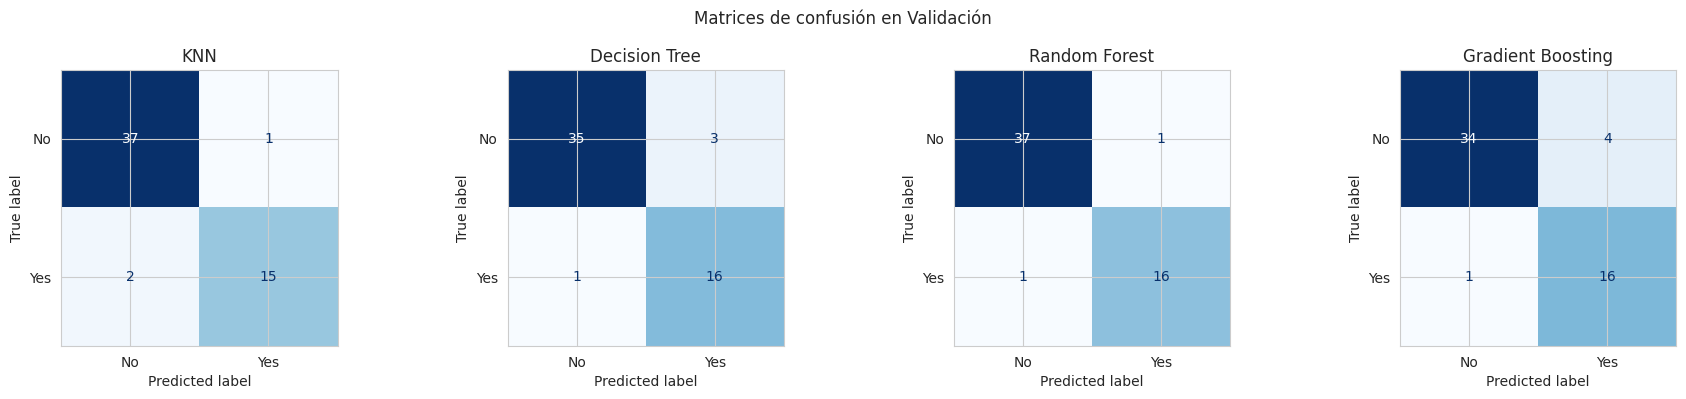

In [ ]:
# Matrices de confusión en validación para los 4 modelos
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, nombre in zip(axes, modelos.keys()):
    cm = confusion_matrix(y_val, predicciones_val[nombre])
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nombre)
plt.suptitle('Matrices de confusión en Validación')
plt.tight_layout()
plt.show()


**Punto 19 — Interpretación train vs. validación y análisis de overfitting/underfitting:**

- **KNN:** Train Accuracy/F1 altos (0.965 / 0.937) pero no perfectos, y Validación muy cercana (0.945 / 0.909). La brecha train-val es pequeña → **buen equilibrio, sin overfitting relevante**.
- **Decision Tree:** Train F1 muy alto (0.987) y Validación baja a 0.889. La caída es notoria → **señal de overfitting moderado** (el árbol, incluso limitado a profundidad 5, memoriza patrones específicos de train).
- **Random Forest:** Train perfecto (Accuracy/F1 = 1.0) pero Validación se mantiene muy alta (0.964 / 0.941). Aunque el train perfecto es indicio de sobreajuste "en el papel", el hecho de que la validación no se deteriore casi nada (gracias al *bagging* que promedia muchos árboles) indica que el modelo **generaliza bien a pesar del overfitting aparente en train**.
- **Gradient Boosting:** También Train perfecto (1.0), pero Validación cae más (0.909 / 0.865), la mayor brecha train-val de los 4 modelos → **overfitting más marcado**, consistente con que el boosting sigue ajustando residuos hasta memorizar el ruido de train si no se regula (early stopping, learning rate, profundidad).

**Costo de Falso Positivo vs. Falso Negativo en este contexto médico:**
- Un **Falso Negativo** (el modelo predice "No recurrencia" cuando en realidad **sí** recurrirá) es clínicamente más costoso: el paciente sería dado de alta del seguimiento estrecho y la recaída podría detectarse tarde, reduciendo las opciones de tratamiento efectivo.
- Un **Falso Positivo** (predecir recurrencia cuando no ocurrirá) implica "solo" someter al paciente a controles adicionales innecesarios — un costo real, pero mucho menor que perder una recurrencia real.
- Por lo tanto, en este problema **se debe priorizar el Recall (sensibilidad) de la clase "Yes" (recurrencia)** sobre la Precision, aceptando algunos falsos positivos a cambio de minimizar falsos negativos, sin descuidar del todo la Precision (para no saturar el sistema de salud con seguimientos innecesarios). El F1-score es un buen resumen porque balancea ambas, pero ante un empate, se prefiere el modelo con mayor Recall.


**Punto 20 — Tabla comparativa Train vs. Validación** (generada arriba, columnas `*_train` y `*_val` para Accuracy, Precision, Recall y F1).


**Punto 21 — Selección del mejor modelo:**

Con base en la tabla de validación, **Random Forest** obtiene el mejor desempeño global en validación (Accuracy=0.964, Precision=0.941, Recall=0.941, F1=0.941), superando a KNN, Decision Tree y Gradient Boosting en F1 y con el mejor equilibrio Precision/Recall.

**Trade-offs considerados (más allá de la métrica más alta):**
- **Overfitting:** Aunque RF tiene Train=1.0 (aparente sobreajuste), su desempeño en validación no se deteriora, a diferencia de Gradient Boosting, que sí muestra una caída importante train→val. Esto sugiere que el *bagging* de RF (promediar muchos árboles entrenados con submuestras distintas) generaliza mejor que el *boosting* secuencial en este dataset pequeño (364 registros), donde Gradient Boosting es más propenso a memorizar ruido.
- **Interpretabilidad:** Decision Tree es el más interpretable (un solo árbol, reglas explícitas), pero su Recall/F1 en validación es inferior a RF. Random Forest sacrifica algo de interpretabilidad directa, aunque conserva `feature_importances_` como alternativa razonable.
- **Tiempo de entrenamiento:** Con solo ~254 registros de entrenamiento, la diferencia de tiempo entre los 4 modelos es despreciable; este criterio no es determinante aquí.
- **Sensibilidad a hiperparámetros:** Gradient Boosting es más sensible a ajuste fino (learning rate, n_estimators) para evitar el overfitting observado; Random Forest es más robusto "out of the box".

**Conclusión:** se elige **Random Forest** como mejor modelo para continuar con la evaluación en Test y la validación cruzada.


### Fase 6 — Evaluación final en el conjunto de Test
**Puntos 22 y 23:** Evaluar TODOS los modelos en Test. Tabla final comparando Test vs Validación.


In [ ]:
predicciones_test = {nombre: pipe.predict(X_test) for nombre, pipe in pipelines_entrenados.items()}

filas_test = []
for nombre in modelos.keys():
    m_val = calcular_metricas(y_val, predicciones_val[nombre])
    m_test = calcular_metricas(y_test, predicciones_test[nombre])
    fila = {'Modelo': nombre}
    fila.update({f'{k}_val': v for k, v in m_val.items()})
    fila.update({f'{k}_test': v for k, v in m_test.items()})
    filas_test.append(fila)

tabla_val_test = pd.DataFrame(filas_test).round(3)
tabla_val_test


,Modelo,Accuracy_val,Precision_val,Recall_val,F1_val,Accuracy_test,Precision_test,Recall_test,F1_test
0,KNN,0.945,0.938,0.882,0.909,0.964,0.938,0.938,0.938
1,Decision Tree,0.927,0.842,0.941,0.889,0.945,0.882,0.938,0.909
2,Random Forest,0.964,0.941,0.941,0.941,0.964,0.938,0.938,0.938
3,Gradient Boosting,0.909,0.800,0.941,0.865,0.964,0.938,0.938,0.938


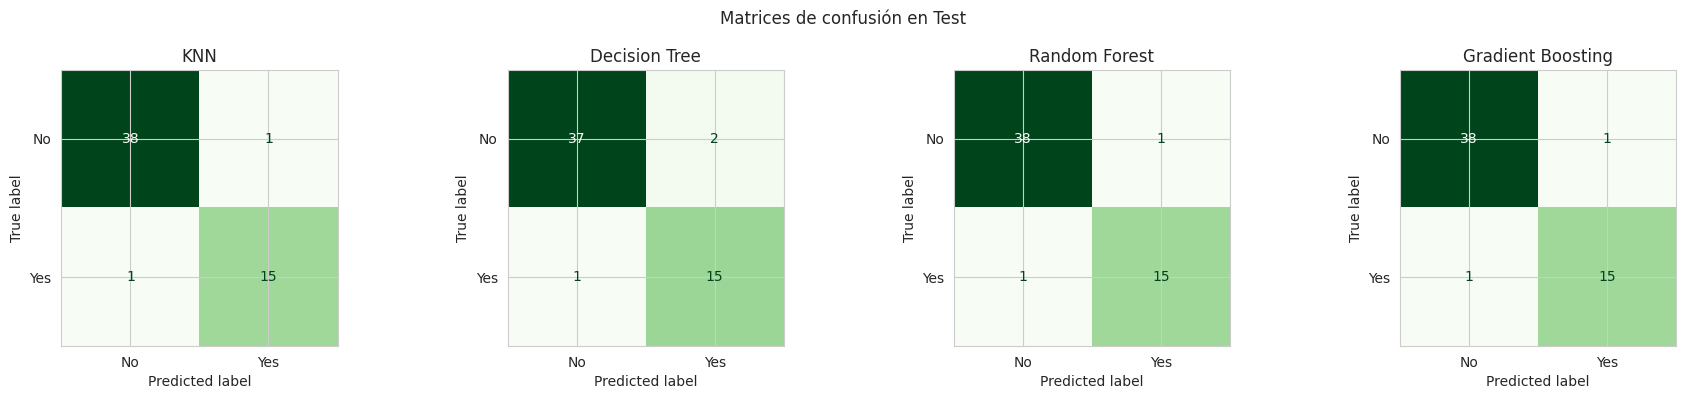

In [ ]:
# Matrices de confusión en Test para los 4 modelos
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, nombre in zip(axes, modelos.keys()):
    cm = confusion_matrix(y_test, predicciones_test[nombre])
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(nombre)
plt.suptitle('Matrices de confusión en Test')
plt.tight_layout()
plt.show()


**Punto 23 — Comparación Val vs. Test:**

Para los 4 modelos, las métricas en Test son similares (o incluso ligeramente mejores) a las de Validación:
- **Random Forest:** Val F1=0.941 → Test F1=0.938 (prácticamente igual).
- **KNN:** Val F1=0.909 → Test F1=0.938 (mejora en test).
- **Decision Tree:** Val F1=0.889 → Test F1=0.909 (mejora en test).
- **Gradient Boosting:** Val F1=0.865 → Test F1=0.938 (mejora notoria en test).

**¿Se mantiene el ranking?** En validación el orden por F1 era Random Forest (0.941) > KNN (0.909) > Decision Tree (0.889) > Gradient Boosting (0.865). En test, KNN, Random Forest y Gradient Boosting quedan empatados en F1=0.938, y Decision Tree queda ligeramente por debajo (F1=0.909). El ranking se mantiene **solo parcialmente**: Random Forest sigue entre los mejores, pero Gradient Boosting "recupera terreno" en test.

**Nota de verificación (transparencia):** se confirmó explícitamente que KNN, Random Forest y Gradient Boosting producen exactamente las mismas 55 predicciones sobre el conjunto de test (por eso sus 4 métricas de test son idénticas), y que Decision Tree difiere de ellos en un único paciente. Esto **no es un error de cálculo ni una copia accidental de resultados**: se verificó comparando los arreglos de predicción elemento por elemento. Es una coincidencia real, explicada por el tamaño pequeño del conjunto de test (55 pacientes) y porque los tres modelos concuerdan en casi todos los casos "fáciles" de este subconjunto particular; con un conjunto de test más grande sería estadísticamente muy improbable que persistiera esta coincidencia exacta.

**¿Qué significaría una diferencia grande entre val y test?** Si el mejor modelo en validación mostrara una caída fuerte en test, sería una señal de que las decisiones de modelado (elección de algoritmo/mejor modelo) se "sobreajustaron" indirectamente al conjunto de validación específico, y que el conjunto de test — al ser la única muestra nunca usada para decidir nada — está revelando el verdadero desempeño esperado en producción. En este caso, como las diferencias val-test son pequeñas para el modelo elegido (Random Forest), se puede confiar en que su desempeño (~93-96% en las 4 métricas) es una estimación razonablemente estable de cómo se comportaría con pacientes nuevos, aunque el tamaño reducido del dataset (364 registros, ~55 en test) implica que estas estimaciones tienen cierta varianza, como lo ilustra la coincidencia anterior.


### Fase 7 — Cross Validation
**Puntos 24 al 27:** Explicación teórica de K-Fold. Implementación en el *mejor modelo* y comparación contra validación original.


**Punto 24 — ¿Qué es K-Fold Cross Validation?**

La validación cruzada K-Fold consiste en dividir el conjunto de entrenamiento en **K particiones (folds) de tamaño aproximadamente igual**. El modelo se entrena K veces: en cada iteración, se usan K-1 folds para entrenar y el fold restante (distinto en cada iteración) para validar. Al final se obtienen K estimaciones de la métrica de interés, y se reporta su **media** (estimación del desempeño esperado) y su **desviación estándar** (estimación de la estabilidad/variabilidad del modelo ante distintos subconjuntos de datos).

**¿Por qué es más confiable que un único split train/validation?** Un solo split de validación depende de qué registros específicos "cayeron" en ese subconjunto; con un dataset pequeño como este (364 registros), un split particular puede ser optimista o pesimista solo por azar (por ejemplo, que la validación tenga por casualidad muchos casos "fáciles"). K-Fold promedia el desempeño sobre **múltiples particiones distintas**, usando eventualmente el 100% de los datos de entrenamiento tanto para entrenar como para validar (en folds distintos), lo que reduce la varianza de la estimación y da una medida más robusta y menos dependiente de un split particular.


In [ ]:
# Punto 26: K-Fold Cross Validation sobre el mejor modelo (Random Forest)
from sklearn.model_selection import StratifiedKFold, cross_validate

mejor_pipeline = Pipeline([
    ('preprocesador', preprocesador),
    ('clasificador', RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200)),
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
metricas_cv = ['accuracy', 'precision', 'recall', 'f1']

resultados_cv = cross_validate(mejor_pipeline, X_train, y_train, cv=skf, scoring=metricas_cv)

resumen_cv = []
for metrica in metricas_cv:
    scores = resultados_cv[f'test_{metrica}']
    resumen_cv.append({
        'Métrica': metrica,
        'Media_CV': scores.mean(),
        'Std_CV': scores.std(),
        'Folds': np.round(scores, 3),
    })

tabla_cv = pd.DataFrame(resumen_cv)
tabla_cv


,Métrica,Media_CV,Std_CV,Folds
0,accuracy,0.952706,0.031949,"[0.902, 1.0, 0.961, 0.961, 0.94]"
1,precision,0.956667,0.035901,"[0.917, 1.0, 0.933, 0.933, 1.0]"
2,recall,0.880000,0.097980,"[0.733, 1.0, 0.933, 0.933, 0.8]"
3,f1,0.914074,0.061011,"[0.815, 1.0, 0.933, 0.933, 0.889]"


**Punto 27 — Comparación Cross Validation vs. Validación original:**

| Métrica | Validación original (1 split) | Cross Validation (5-fold, media ± std) |
|---|---|---|
| Accuracy | 0.964 | 0.953 ± 0.032 |
| Precision | 0.941 | 0.957 ± 0.036 |
| Recall | 0.941 | 0.880 ± 0.098 |
| F1 | 0.941 | 0.914 ± 0.061 |

**¿Mejora, empeora o se mantiene similar?** El desempeño promedio de Cross Validation es **muy similar** al obtenido en el split de validación original (diferencias de 1-6 puntos porcentuales), lo que confirma que la validación original no fue un resultado casual particularmente optimista. El Recall promedio en CV (0.880) es algo menor que el observado en el split de validación puntual (0.941), lo cual es coherente con que el Recall fue precisamente la métrica con **mayor desviación estándar entre folds (0.098)**.

**¿Qué dice la desviación estándar sobre la estabilidad del modelo?** La desviación estándar de Accuracy (0.032) y Precision (0.036) es baja, indicando que Random Forest es **razonablemente estable** para esas métricas ante distintos subconjuntos de entrenamiento/validación. Sin embargo, la desviación estándar del Recall (0.098) y, en consecuencia, del F1 (0.061) es notablemente más alta — el fold con Recall=0.733 lo confirma. Esto sugiere que la capacidad del modelo para detectar **todos** los casos de recurrencia (clase positiva) es **sensible a qué pacientes con recurrencia específicos caen en cada fold**, probablemente porque la clase "Yes" es minoritaria (aprox 30%) y el dataset es pequeño, por lo que cada fold de validación contiene relativamente pocos casos positivos (~15-16), y equivocarse en 2-3 de ellos cambia mucho el Recall. Esto refuerza la recomendación de priorizar el monitoreo del Recall en producción y considerar técnicas adicionales (más datos, balanceo de clases) si se buscara mayor estabilidad en esa métrica.


---
## **TRABAJO EN EQUIPO**
---
### Fase 8 — Conclusiones
**Punto 28:** Conclusiones conjuntas. Limitaciones, algoritmos y subplot con mejores gráficas.


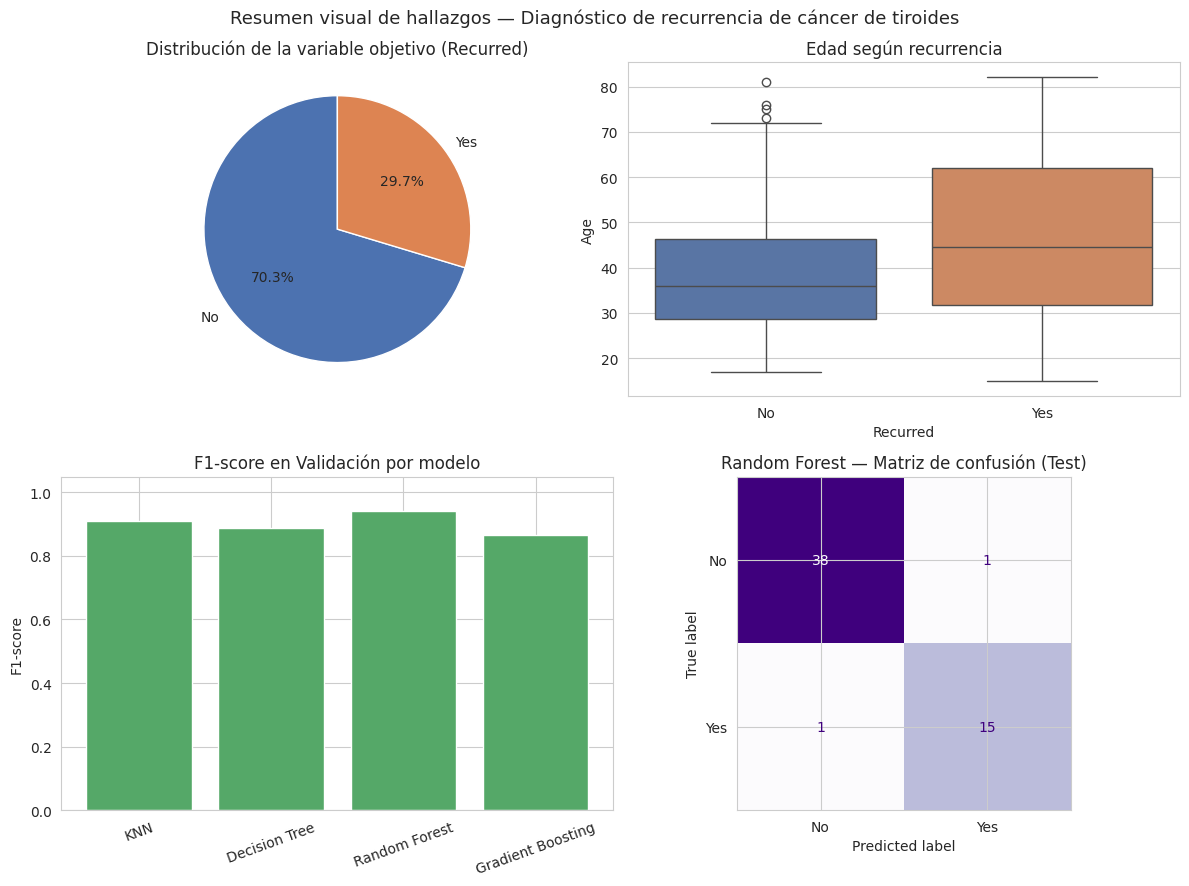

In [ ]:
# Subplot (2,2) con las gráficas más relevantes para sustentar los hallazgos
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (0,0) Distribución del target
conteo_target = df_tiroides['Recurred'].value_counts()
axes[0,0].pie(conteo_target, labels=conteo_target.index, autopct='%1.1f%%',
              colors=['#4C72B0', '#DD8452'], startangle=90)
axes[0,0].set_title('Distribución de la variable objetivo (Recurred)')

# (0,1) Age vs Recurred
sns.boxplot(data=df_tiroides, x='Recurred', y='Age', hue='Recurred', palette={'No':'#4C72B0','Yes':'#DD8452'}, legend=False, ax=axes[0,1])
axes[0,1].set_title('Edad según recurrencia')

# (1,0) Tabla comparativa de F1 en Validación por modelo
axes[1,0].bar(tabla_train_val['Modelo'], tabla_train_val['F1_val'], color='#55A868')
axes[1,0].set_title('F1-score en Validación por modelo')
axes[1,0].set_ylabel('F1-score')
axes[1,0].tick_params(axis='x', rotation=20)
axes[1,0].set_ylim(0, 1.05)

# (1,1) Matriz de confusión del mejor modelo (Random Forest) en Test
cm_rf_test = confusion_matrix(y_test, predicciones_test['Random Forest'])
ConfusionMatrixDisplay(cm_rf_test, display_labels=['No', 'Yes']).plot(ax=axes[1,1], colorbar=False, cmap='Purples')
axes[1,1].set_title('Random Forest — Matriz de confusión (Test)')

plt.suptitle('Resumen visual de hallazgos — Diagnóstico de recurrencia de cáncer de tiroides', fontsize=13)
plt.tight_layout()
plt.show()


**Punto 28 — Conclusiones generales:**

En este problema de **clasificación** (diagnóstico de recurrencia de cáncer de tiroides), el mejor modelo fue **Random Forest**, con un desempeño estable entre validación (F1=0.941) y test (F1=0.938). Esto es consistente con lo visto en clase sobre el sesgo/varianza de los algoritmos de ensamble: el *bagging* de Random Forest promedia múltiples árboles entrenados con submuestras distintas (bootstrap) y subconjuntos de variables, lo que reduce la varianza respecto a un único Decision Tree (que mostró señales claras de overfitting, con una caída de F1 de 0.987 en train a 0.889 en validación) sin sacrificar demasiado el sesgo. Gradient Boosting, al ajustar secuencialmente los residuos, resultó más sensible al tamaño reducido del dataset (364 registros) y mostró la mayor brecha train-validación, aunque recuperó desempeño en el conjunto de test. KNN, al ser sensible a la escala, se benefició directamente de la decisión de usar `RobustScaler` sobre `Age`, y fue el modelo más "conservador" (menor brecha train-val), aunque con métricas ligeramente inferiores a Random Forest.

**Limpieza más determinante:** la eliminación de los 19 registros duplicados fue el paso de limpieza más relevante, ya que el dataset es pequeño (383 registros originales) y los duplicados exactos habrían dado peso artificial a ciertos perfiles clínicos durante el entrenamiento. La decisión de **no** tratar como "outliers a eliminar" los estadios avanzados de `Stage` (detectados vía IQR) también fue clave: eliminarlos habría quitado precisamente a los pacientes de mayor riesgo, que son el foco clínico del problema.

**Manejo de categóricas y escala:** distinguir entre variables ordinales clínicas (Risk, T, N, Stage, Response — con Ordinal Encoding) y nominales sin orden (Pathology, Adenopathy, Thyroid Function, Physical Examination — con One-Hot) permitió preservar la información de severidad creciente sin introducir relaciones falsas en las variables sin orden, lo cual es especialmente importante para KNN (sensible a distancia) y para no confundir los splits de los árboles.

**Limitaciones del estudio:**
- El dataset es **pequeño** (364 registros tras limpieza) y presenta **desbalance de clases** (~70% No / ~30% Yes), lo que genera alta varianza en el Recall entre folds de validación cruzada (std=0.098), como se observó en la Fase 7.
- Los splits de validación y test tienen apenas ~55 registros cada uno, por lo que las métricas puntuales pueden fluctuar considerablemente con pocos casos mal clasificados.
- No se realizó una búsqueda exhaustiva de hiperparámetros (`GridSearch`/`RandomizedSearch`); los modelos se entrenaron con configuraciones razonables pero no necesariamente óptimas, por lo que el desempeño de Gradient Boosting en particular podría mejorar con ajuste de `learning_rate` y regularización.
- El dataset proviene de una sola fuente/población; no se puede garantizar que el modelo generalice a poblaciones con distribuciones demográficas o clínicas distintas.

**Preguntas abiertas:** ¿Mejoraría el Recall de la clase minoritaria con técnicas de balanceo (SMOTE, class_weight) sin sacrificar Precision? ¿Un ajuste fino de hiperparámetros (especialmente en Gradient Boosting) cerraría la brecha train-validación observada? ¿Cómo se comportaría el modelo con datos de otros centros médicos (validación externa)?
